In [1]:
import os
os.chdir('../../../../../..')

In [1]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import gc
import numpy as np
import polars as pl
from dscribe.descriptors import SOAP
from rdkit import Chem
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split




from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP
from dscribe.kernels import REMatchKernel

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

ModuleNotFoundError: No module named 'src'

In [3]:
qm9 = QM9Dataset(limit=50_000, descriptors=["transformer"])
df = qm9.load()

2026-05-22 08:39:14.428 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-22 08:39:15.131 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=50000, returned_rows=50000, sampling on columns=['num_atoms', 'gap'].
2026-05-22 08:39:15.133 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=50000).
2026-05-22 08:39:15.133 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDat

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-05-22 08:44:22.695 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['selfies_transformer']


In [21]:
import torch
from transformers import AutoTokenizer, AutoModel

def compute_selfies_transformer(selfies_series: pl.Series, 
                                    model_name: str = "HUBioDataLab/SELFormer", 
                                    batch_size: int = 32) -> pl.Series:
        """
        Computes molecular embeddings using the SELFormer encoder-only architecture.
        """

        device = 'mps'
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True, output_hidden_states=True).to(device)
        model.eval()
        clean_selfies = [s.replace("][", "] [") if s else "[nop]" for s in selfies_series.to_list()]
        embeddings = []
        
        with torch.no_grad():
            for i in range(0, len(clean_selfies), batch_size):
                batch = clean_selfies[i : i + batch_size]
                
                inputs = tokenizer(
                    batch, 
                    padding=True, 
                    truncation=True, 
                    max_length=256,
                    return_tensors="pt"
                ).to(device)
                
                outputs = model(**inputs)
                
                #hidden_states = outputs.last_hidden_state
                hidden_states = outputs.hidden_states[6]
                
                mask = inputs["attention_mask"].unsqueeze(-1).expand(hidden_states.size()).float()
                sum_embeddings = torch.sum(hidden_states * mask, dim=1)
                sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
                mean_pooled = sum_embeddings / sum_mask
                
                embeddings.extend(mean_pooled.cpu().tolist())

        return pl.Series("selfies_transformer", embeddings)

# Hypothesis 1
- it can manage shuffled selfies strings

In [14]:
from time import time
from tqdm import tqdm
import random
import selfies as sf

def generate_augmentations(smiles_str, num_variants=20, timeout=1):
    """Generates unique randomized SMILES for a single input molecule."""
    mol = Chem.MolFromSmiles(smiles_str)
    mol = Chem.RemoveHs(mol)
    if not mol:
        return []
    
    unique_variants = {Chem.MolToSmiles(mol, canonical=True)}
    start_time = time()
    
    while len(unique_variants) < num_variants:
        if (time() - start_time) > timeout:
            break
        
        # doRandom=True creates a new valid path through the molecular graph
        v = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        unique_variants.add(v)
        
    return list(unique_variants)

# 1. Filter and Sample
long_smiles = [s for s in df['smiles'] if len(s) > 50]
sample_pool = random.sample(long_smiles, min(len(long_smiles), 50))
chosen_smiles = []

# 2. Process
all_combinations = []
selfies_variants = []
i = 0
for s in tqdm(sample_pool, desc="Augmenting Molecules"):
    variants = generate_augmentations(s, num_variants=20)
    
    if len(variants) < 20:
        tqdm.write(f"Note: Only generated {len(variants)} variants for a molecule (timeout).")
        continue
    
    chosen_smiles.extend([s]*20)
    all_combinations.append(variants)
    
    i += 1
    if i >= 20:
        break
    
all_combinations = np.array(all_combinations).flatten()
selfies_variants = [sf.encoder(s) for s in all_combinations]

Augmenting Molecules:  38%|███▊      | 19/50 [00:00<00:00, 926.75it/s]


INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


Computing SELFormer embeddings...


INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBio

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


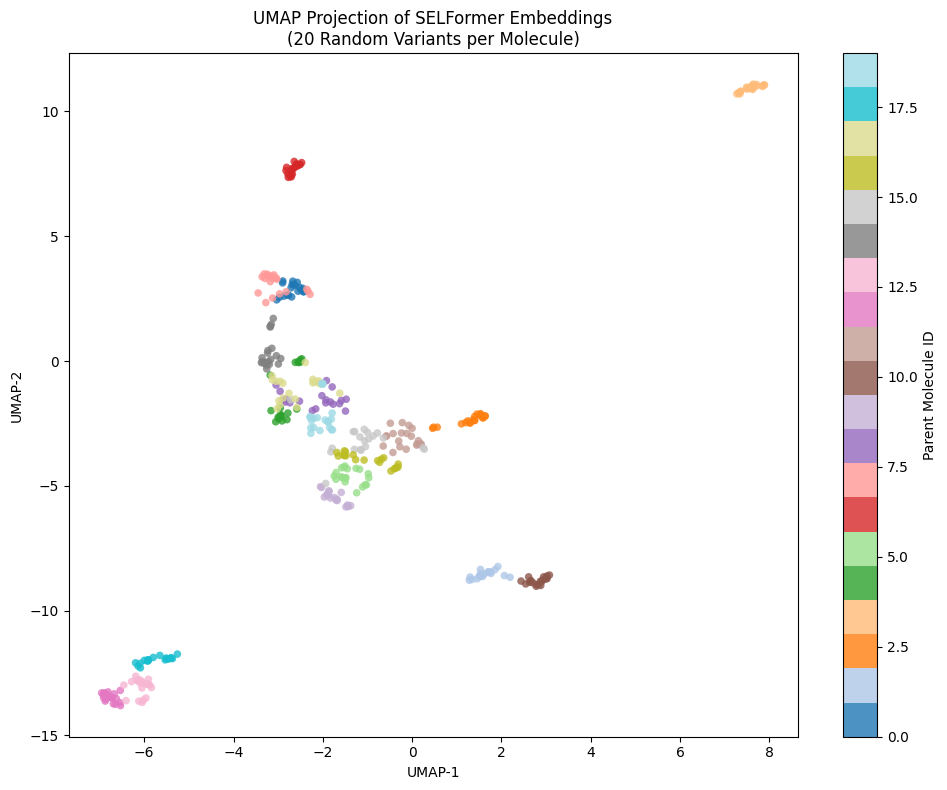

In [22]:
import polars as pl
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt

# --- 1. Map tracking labels to the variants ---
# You selected exactly 20 parent molecules, each with 20 variants.
# Let's create an explicit label ID (0 to 19) for each group of variants.
parent_labels = np.repeat(np.arange(20), 20) 

# Convert your SELFIES list into a Polars Series for your function
selfies_series = pl.Series("selfies", selfies_variants)

# --- 2. Compute the SELFormer Embeddings ---
print("Computing SELFormer embeddings...")
embeddings_series = compute_selfies_transformer(selfies_series, model_name="HUBioDataLab/SELFormer", batch_size=32)

# Convert the Polars Series containing lists into a standard 2D NumPy array
X_embeddings = np.array(embeddings_series.to_list())

# --- 3. Project onto 2D Space using UMAP ---
# We bypass PCA here because UMAP is highly efficient at capturing both global 
# and local structural similarities directly from the high-dimensional embeddings.
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
X_umap = reducer.fit_transform(X_embeddings)

# --- 4. Plot the results ---
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=parent_labels, 
    cmap="tab20",  # Qualitative colormap with 20 distinct colors
    alpha=0.8, 
    edgecolors='none',
    s=30
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Projection of SELFormer Embeddings\n(20 Random Variants per Molecule)")
plt.colorbar(scatter, label="Parent Molecule ID")
plt.tight_layout()
plt.show()

=== Embedding Space Distance Metrics ===
Intra-Molecule Distance (Same Parent):  Mean = 2.7593 ± 0.7398
Inter-Molecule Distance (Diff Parents): Mean = 4.3957 ± 1.1589
Intra/Inter Distance Ratio:             0.6277


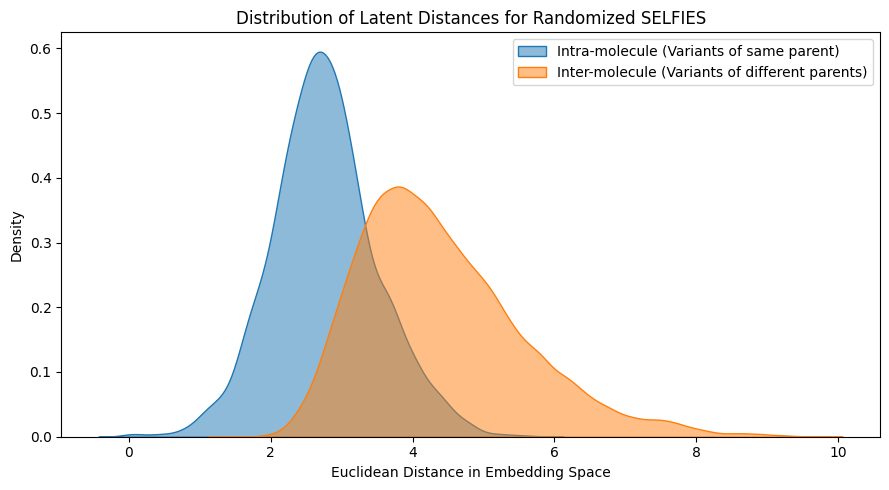

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

# 1. Compute the full pairwise Euclidean distance matrix
# Shape will be (400, 400) since you have 20 parents * 20 variants
dist_matrix = euclidean_distances(X_embeddings)

# 2. Extract intra and inter metrics
intra_distances = []
inter_distances = []

# Labels tracking which parent index (0 to 19) each row belongs to
parent_labels = np.repeat(np.arange(20), 20)

for i in range(len(parent_labels)):
    for j in range(i + 1, len(parent_labels)):  # Symmetric matrix, skip duplicates/self
        dist = dist_matrix[i, j]
        if parent_labels[i] == parent_labels[j]:
            intra_distances.append(dist)
        else:
            inter_distances.append(dist)

# Convert to arrays for statistical summaries
intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

# 3. Print Statistical Summary
print("=== Embedding Space Distance Metrics ===")
print(f"Intra-Molecule Distance (Same Parent):  Mean = {intra_distances.mean():.4f} ± {intra_distances.std():.4f}")
print(f"Inter-Molecule Distance (Diff Parents): Mean = {inter_distances.mean():.4f} ± {inter_distances.std():.4f}")

# Calculate Ratio (Lower is better: indicates tight clusters far apart)
ratio = intra_distances.mean() / inter_distances.mean()
print(f"Intra/Inter Distance Ratio:             {ratio:.4f}")

# 4. Plot the Distribution Overlap
plt.figure(figsize=(9, 5))
sns.kdeplot(intra_distances, label="Intra-molecule (Variants of same parent)", fill=True, alpha=0.5)
sns.kdeplot(inter_distances, label="Inter-molecule (Variants of different parents)", fill=True, alpha=0.5)
plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Density")
plt.title("Distribution of Latent Distances for Randomized SELFIES")
plt.legend()
plt.tight_layout()
plt.show()

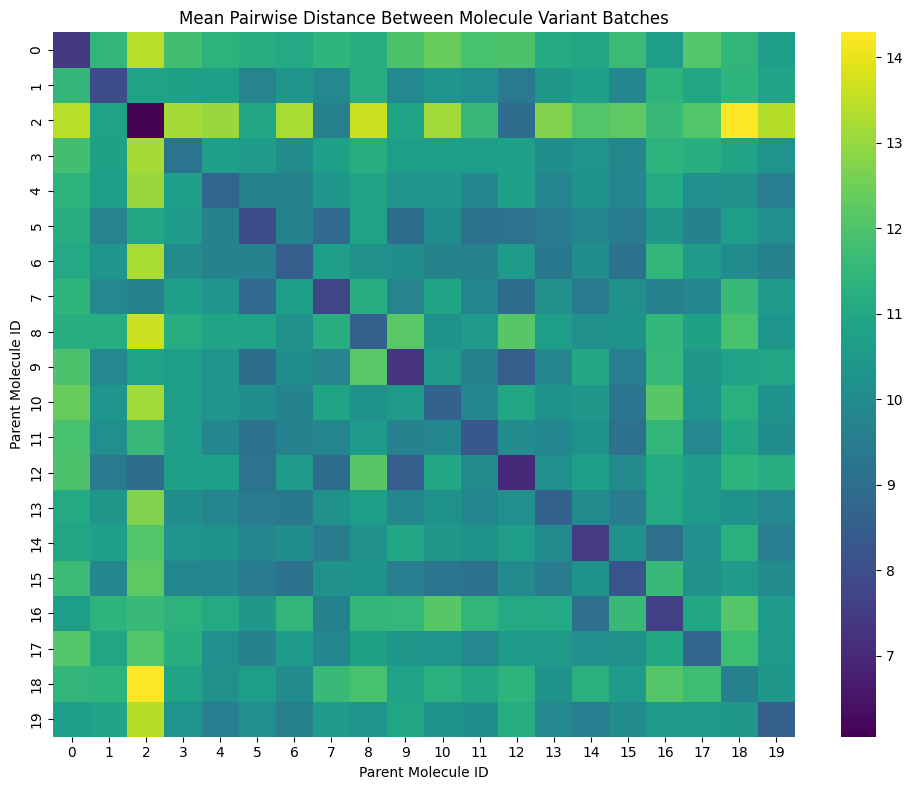

In [12]:
# Compute average distance between the 20 clusters
macro_dist_matrix = np.zeros((20, 20))

for i in range(20):
    for j in range(20):
        # Slice out the 20x20 block representing distances between parent i and parent j
        block = dist_matrix[i*20 : (i+1)*20, j*20 : (j+1)*20]
        macro_dist_matrix[i, j] = block.mean()

# Plotting the macro cluster distance heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(macro_dist_matrix, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Mean Pairwise Distance Between Molecule Variant Batches")
plt.xlabel("Parent Molecule ID")
plt.ylabel("Parent Molecule ID")
plt.tight_layout()
plt.show()

# Hypo 2

In [36]:
df_carbolic_acid = df.filter(pl.col("functional_groups") == "carboxylic_acid").sample(20)
df_halogen = df.filter(pl.col("functional_groups") == "halogen").sample(20)
df_nitro = df.filter(pl.col("functional_groups") == "nitro").sample(20)

In [37]:
df_exp2 = pl.concat([df_carbolic_acid, df_halogen, df_nitro])

Extracting chemical semantic features from SELFormer Layer 6...


INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"



=== Clustering Performance ===
Global Silhouette Score: 0.1909


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


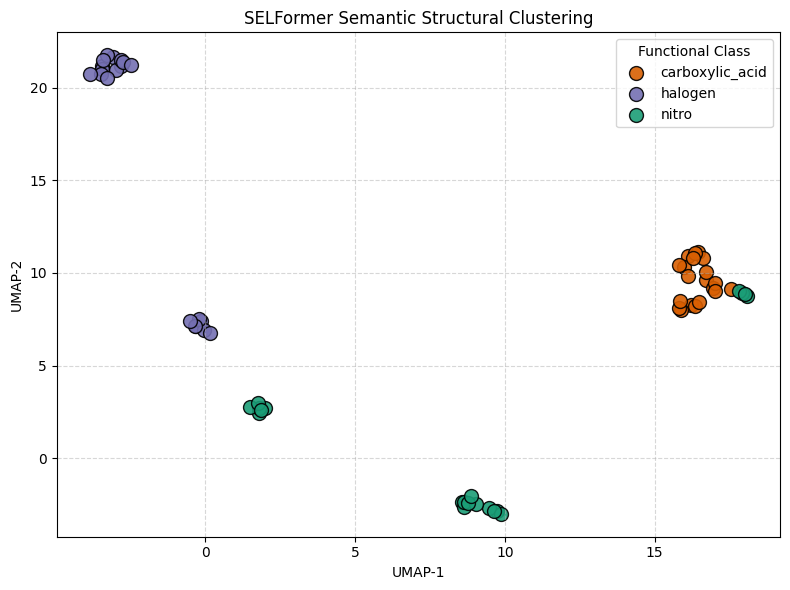

In [49]:
import polars as pl
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from umap import UMAP
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# ==========================================
# 2. Optimized Embedding Extraction Function
# ==========================================
def compute_semantic_embeddings(selfies_series: pl.Series, layer_idx: int = 6) -> np.ndarray:
    device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = "HUBioDataLab/SELFormer"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True, output_hidden_states=True).to(device)
    model.eval()
    
    clean_selfies = [s.replace("][", "] [") if s else "[nop]" for s in selfies_series.to_list()]
    embeddings = []
    
    with torch.no_grad():
        for s in clean_selfies:
            inputs = tokenizer(s, return_tensors="pt").to(device)
            outputs = model(**inputs)
            
            # Extract the robust intermediate hidden states
            hidden_states = outputs.hidden_states[layer_idx]
            
            # Mean pool across sequence length
            mean_pooled = torch.mean(hidden_states, dim=1)
            embeddings.append(mean_pooled.squeeze().cpu().numpy())
            
    return np.array(embeddings)

print("Extracting chemical semantic features from SELFormer Layer 6...")
X_embeddings = compute_semantic_embeddings(df_exp2["selfies"], layer_idx=6)
labels = df_exp2["functional_groups"].to_list()

# ==========================================
# 3. Quantitative Evaluation
# ==========================================
# Silhouette score checks cluster separation in the raw embedding space
# Score > 0 implies valid separation; Score near 1 implies perfect separation
sil_score = silhouette_score(X_embeddings, labels)
print(f"\n=== Clustering Performance ===")
print(f"Global Silhouette Score: {sil_score:.4f}")

# ==========================================
# 4. Dimensionality Reduction & Visualization
# ==========================================
reducer = UMAP(n_neighbors=5, metric="euclidean", random_state=42)
X_umap = reducer.fit_transform(X_embeddings)

plt.figure(figsize=(8, 6))
unique_groups = sorted(list(set(labels)))
colors = ['#d95f02', '#7570b3', '#1b9e77'] # Distinct qualitative palette

for idx, group in enumerate(unique_groups):
    mask = [i for i, l in enumerate(labels) if l == group]
    plt.scatter(
        X_umap[mask, 0], 
        X_umap[mask, 1], 
        label=group, 
        c=colors[idx], 
        s=100, 
        alpha=0.9, 
        edgecolors='black'
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("SELFormer Semantic Structural Clustering")
plt.legend(title="Functional Class")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import pairwise_distances
from umap import UMAP
dist_matrix = pairwise_distances(np.array(X_embeddings), metric="euclidean")

In [45]:
unique_groups = sorted(list(set(labels)))
label_to_idx = {group: i for i, group in enumerate(unique_groups)}

# Map the original string list to integers
numeric_labels = [label_to_idx[l] for l in labels]
create_chemiscope_viewer(df_exp2, dist_matrix, numeric_labels, 'UMAP')

2026-05-22 09:42:38.771 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-22 09:42:38.771 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-22 09:42:38.956 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 5
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-22 09:42:38.993 | INFO     | src.helper_f

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …


=== Embedding Space Distance Metrics ===
Intra-Cluster Distance (Same Group):  Mean = 3.5536 ± 1.1248
Inter-Cluster Distance (Diff Groups): Mean = 4.8122 ± 1.0507
Intra/Inter Distance Ratio:           0.7385


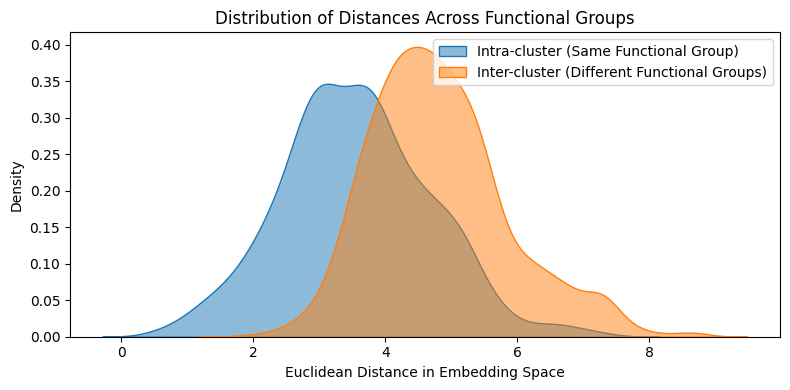

In [50]:
# ==========================================
# 3b. Pairwise Inter- and Intra-Cluster Distances
# ==========================================
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

# 1. Compute the full pairwise Euclidean distance matrix
dist_matrix = euclidean_distances(X_embeddings)

intra_distances = []
inter_distances = []

# 2. Extract distances based on matching/non-matching functional groups
n_samples = len(labels)
for i in range(n_samples):
    for j in range(i + 1, n_samples):  # Symmetric matrix, avoid self-comparison
        dist = dist_matrix[i, j]
        if labels[i] == labels[j]:
            intra_distances.append(dist)
        else:
            inter_distances.append(dist)

intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

# 3. Print Statistical Metrics
print("\n=== Embedding Space Distance Metrics ===")
print(f"Intra-Cluster Distance (Same Group):  Mean = {intra_distances.mean():.4f} ± {intra_distances.std():.4f}")
print(f"Inter-Cluster Distance (Diff Groups): Mean = {inter_distances.mean():.4f} ± {inter_distances.std():.4f}")

# Ratio < 1.0 indicates that clusters are tighter internally than the distance between them
ratio = intra_distances.mean() / inter_distances.mean()
print(f"Intra/Inter Distance Ratio:           {ratio:.4f}")

# 4. Plot Distribution Overlap
plt.figure(figsize=(8, 4))
sns.kdeplot(intra_distances, label="Intra-cluster (Same Functional Group)", fill=True, alpha=0.5, color='#1f77b4')
sns.kdeplot(inter_distances, label="Inter-cluster (Different Functional Groups)", fill=True, alpha=0.5, color='#ff7f0e')
plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Density")
plt.title("Distribution of Distances Across Functional Groups")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# ==========================================
# 3d. Conditional 1-NN Distances (Same vs Diff Group)
# ==========================================
from sklearn.metrics.pairwise import euclidean_distances

# Compute the full pairwise distance matrix
dist_matrix = euclidean_distances(X_embeddings)

same_group_1nn_distances = []
diff_group_1nn_distances = []

n_samples = len(labels)
labels_arr = np.array(labels)

for i in range(n_samples):
    current_label = labels[i]
    
    # Create masks to separate neighbors
    same_mask = (labels_arr == current_label)
    same_mask[i] = False  # False for itself so we don't pick a distance of 0.0
    
    diff_mask = (labels_arr != current_label)
    
    # Get all distances from molecule i to others
    row_distances = dist_matrix[i]
    
    # 1-NN distance within the same functional group
    if np.any(same_mask):
        same_group_1nn = np.min(row_distances[same_mask])
        same_group_1nn_distances.append(same_group_1nn)
        
    # 1-NN distance to the closest entirely different functional group
    if np.any(diff_mask):
        diff_group_1nn = np.min(row_distances[diff_mask])
        diff_group_1nn_distances.append(diff_group_1nn)

same_group_1nn_distances = np.array(same_group_1nn_distances)
diff_group_1nn_distances = np.array(diff_group_1nn_distances)

print("\n=== Conditional Local 1-NN Metrics ===")
print(f"Average 1-NN (Same Group):            Mean = {same_group_1nn_distances.mean():.4f} ± {same_group_1nn_distances.std():.4f}")
print(f"Average 1-NN (Different Group):       Mean = {diff_group_1nn_distances.mean():.4f} ± {diff_group_1nn_distances.std():.4f}")

# A local ratio significantly below 1.0 confirms clean local cluster boundaries
local_ratio = same_group_1nn_distances.mean() / diff_group_1nn_distances.mean()
print(f"Local 1-NN Ratio (Same/Diff):         {local_ratio:.4f}")
print("=========================================\n")


=== Conditional Local 1-NN Metrics ===
Average 1-NN (Same Group):            Mean = 1.7781 ± 0.8104
Average 1-NN (Different Group):       Mean = 3.4537 ± 0.7277
Local 1-NN Ratio (Same/Diff):         0.5148

